<h2><b>Data Science Assignment 5</b></h2>

<h3><b>By: Alex Litchfield</b></h3>

In [95]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score, f1_score, classification_report


# fetch dataset from https://archive.ics.uci.edu/dataset/602/dry+bean+dataset
dry_bean = fetch_ucirepo(id = 602) 
  
# data (as pandas dataframes) 
X = dry_bean.data.features 
y = dry_bean.data.targets 
metadata = dry_bean.metadata
variables = dry_bean.variables
df = pd.concat([X, y], axis = 1)

In [96]:
metadata

{'uci_id': 602,
 'name': 'Dry Bean',
 'repository_url': 'https://archive.ics.uci.edu/dataset/602/dry+bean+dataset',
 'data_url': 'https://archive.ics.uci.edu/static/public/602/data.csv',
 'abstract': 'Images of 13,611 grains of 7 different registered dry beans were taken with a high-resolution camera. A total of 16 features; 12 dimensions and 4 shape forms, were obtained from the grains.',
 'area': 'Biology',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 13611,
 'num_features': 16,
 'feature_types': ['Integer', 'Real'],
 'demographics': [],
 'target_col': ['Class'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 2020,
 'last_updated': 'Thu Mar 28 2024',
 'dataset_doi': '10.24432/C50S4B',
 'creators': [],
 'intro_paper': {'ID': 244,
  'type': 'NATIVE',
  'title': 'Multiclass classification of dry beans using computer vision and machine learning techniques',
  'authors': 'M. Koklu, Ilke

In [97]:
# Display description of each feature
for i in range(len(variables['name'])):
    print(variables['name'][i], '-', variables['description'][i])

print(variables)

Area - The area of a bean zone and the number of pixels within its boundaries
Perimeter - Bean circumference is defined as the length of its border.
MajorAxisLength - The distance between the ends of the longest line that can be drawn from a bean
MinorAxisLength - The longest line that can be drawn from the bean while standing perpendicular to the main axis
AspectRatio - Defines the relationship between MajorAxisLength and MinorAxisLength
Eccentricity - Eccentricity of the ellipse having the same moments as the region
ConvexArea - Number of pixels in the smallest convex polygon that can contain the area of a bean seed
EquivDiameter - Equivalent diameter: The diameter of a circle having the same area as a bean seed area
Extent - The ratio of the pixels in the bounding box to the bean area
Solidity - Also known as convexity. The ratio of the pixels in the convex shell to those found in beans.
Roundness - Calculated with the following formula: (4piA)/(P^2)
Compactness - Measures the round

In [98]:
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [99]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860154,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [100]:
df.shape

(13611, 17)

<h3><b>Q1. Exploratory Data Analysis</b></h3>

<h4><b>Data Cleaning</b></h4>

In [101]:
# Checking to see if there are any missing values in different columns
print(df.isna().sum())
# Since there are no missing values in any columns, no cleaning is needed

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRatio        0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
Roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64


In [102]:
# Only take the first 5 columns
df = df[['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRatio']]
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio
0,28395,610.291,208.178117,173.888747,1.197191
1,28734,638.018,200.524796,182.734419,1.097356
2,29380,624.110,212.826130,175.931143,1.209713
3,30008,645.884,210.557999,182.516516,1.153638
4,30140,620.134,201.847882,190.279279,1.060798


In [103]:
# Removing outliers from data
q1 = df.quantile(0.25)
q3 = df.quantile(0.75)
iqr = q3 - q1
df_no_outliers = df[~ ((df < (q1 - 1.5 * iqr)) | (df > (q3 + 1.5 * iqr))).any(axis = 1)]
df_no_outliers.shape

(12552, 5)

<h4><b>Histograms for data (including outliers)</b></h4>

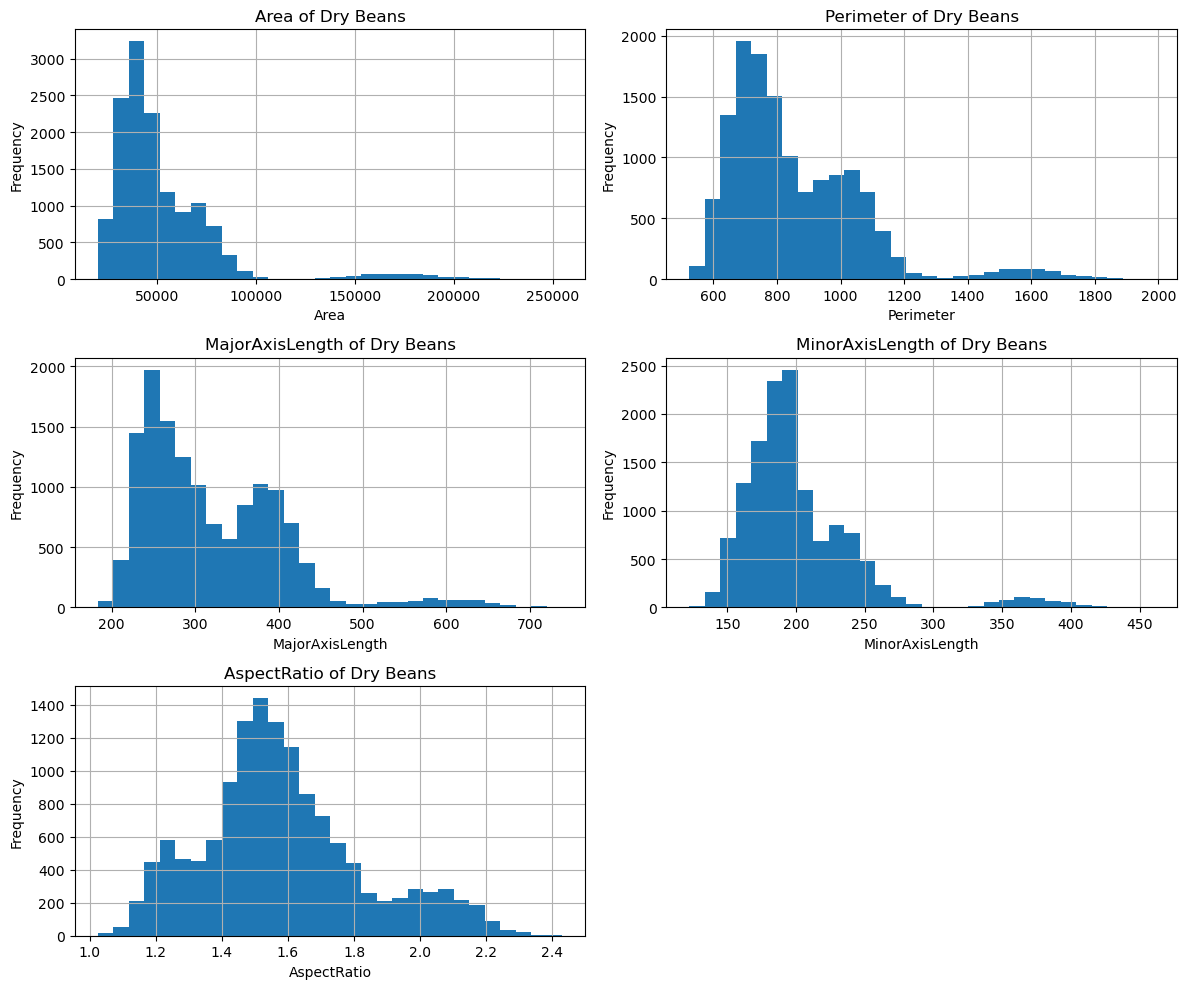

In [104]:
# Plots histograms for each metric
axes = df.hist(figsize = (12, 10), bins = 30)
for ax in axes.ravel():
    ax.set_xlabel(ax.get_title())
    ax.set_ylabel("Frequency")
    ax.set_title((ax.get_title() + " of Dry Beans"))
plt.tight_layout()
plt.show()

<h4><b>Histograms for data (NOT including outliers)</b></h4>

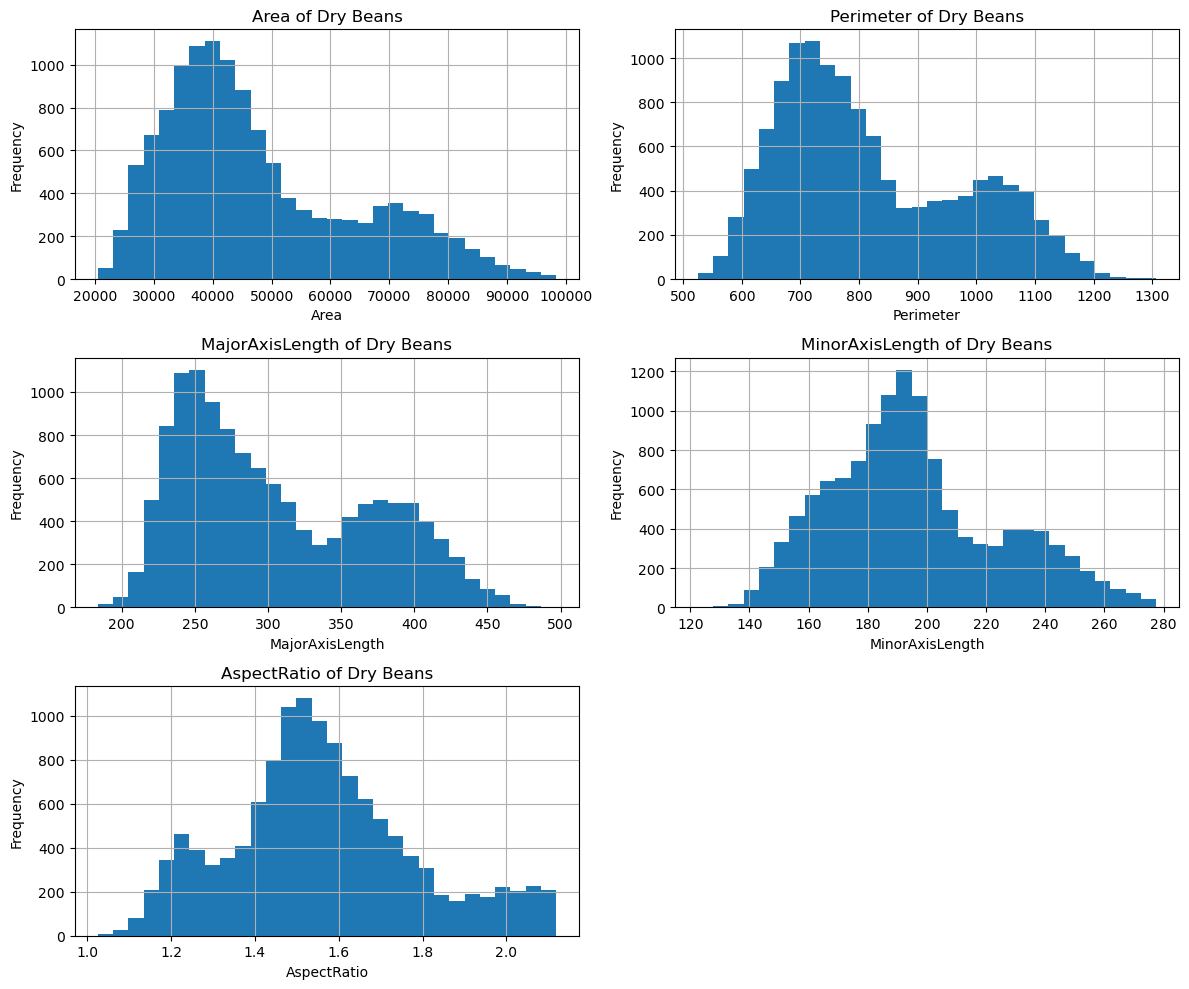

In [105]:
# Plots histograms for each metric (NO OUTLIERS)
axes = df_no_outliers.hist(figsize = (12, 10), bins = 30)
for ax in axes.ravel():
    ax.set_xlabel(ax.get_title())
    ax.set_ylabel("Frequency")
    ax.set_title((ax.get_title() + " of Dry Beans"))
plt.tight_layout()
plt.show()

<h4><b>Boxplots for data (including outliers)</b></h4>

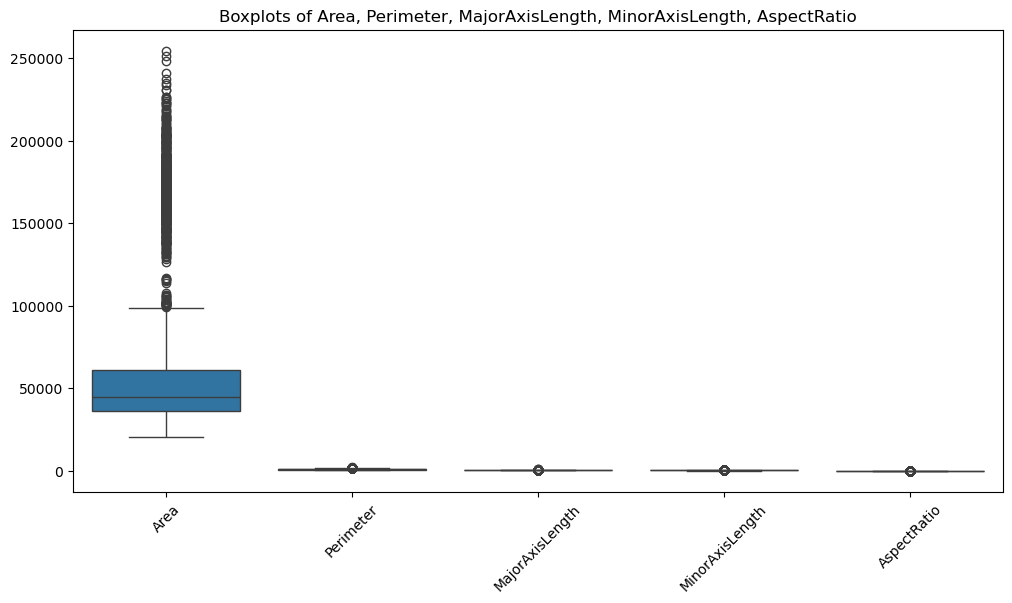

In [106]:
# Creating boxplot for the provided metrics
plt.figure(figsize = (12, 6))
sns.boxplot(data = df)
plt.xticks(rotation = 45)
plt.title("Boxplots of Area, Perimeter, MajorAxisLength, MinorAxisLength, AspectRatio")
plt.show()

<h4><b>Boxplots for data (NOT including outliers)</b></h4>

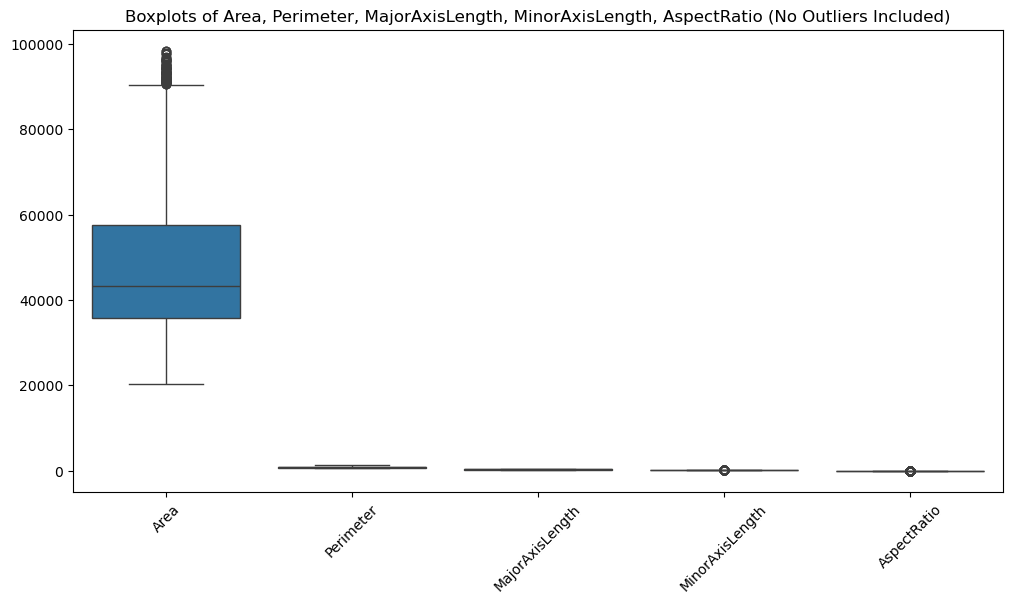

In [107]:
# Creating boxplot for the provided metrics (NO OUTLIERS)
plt.figure(figsize = (12, 6))
sns.boxplot(data = df_no_outliers)
plt.xticks(rotation = 45)
plt.title("Boxplots of Area, Perimeter, MajorAxisLength, MinorAxisLength, AspectRatio (No Outliers Included)")
plt.show()

<h4><b>Scatterplot for data (including outliers)</b></h4>

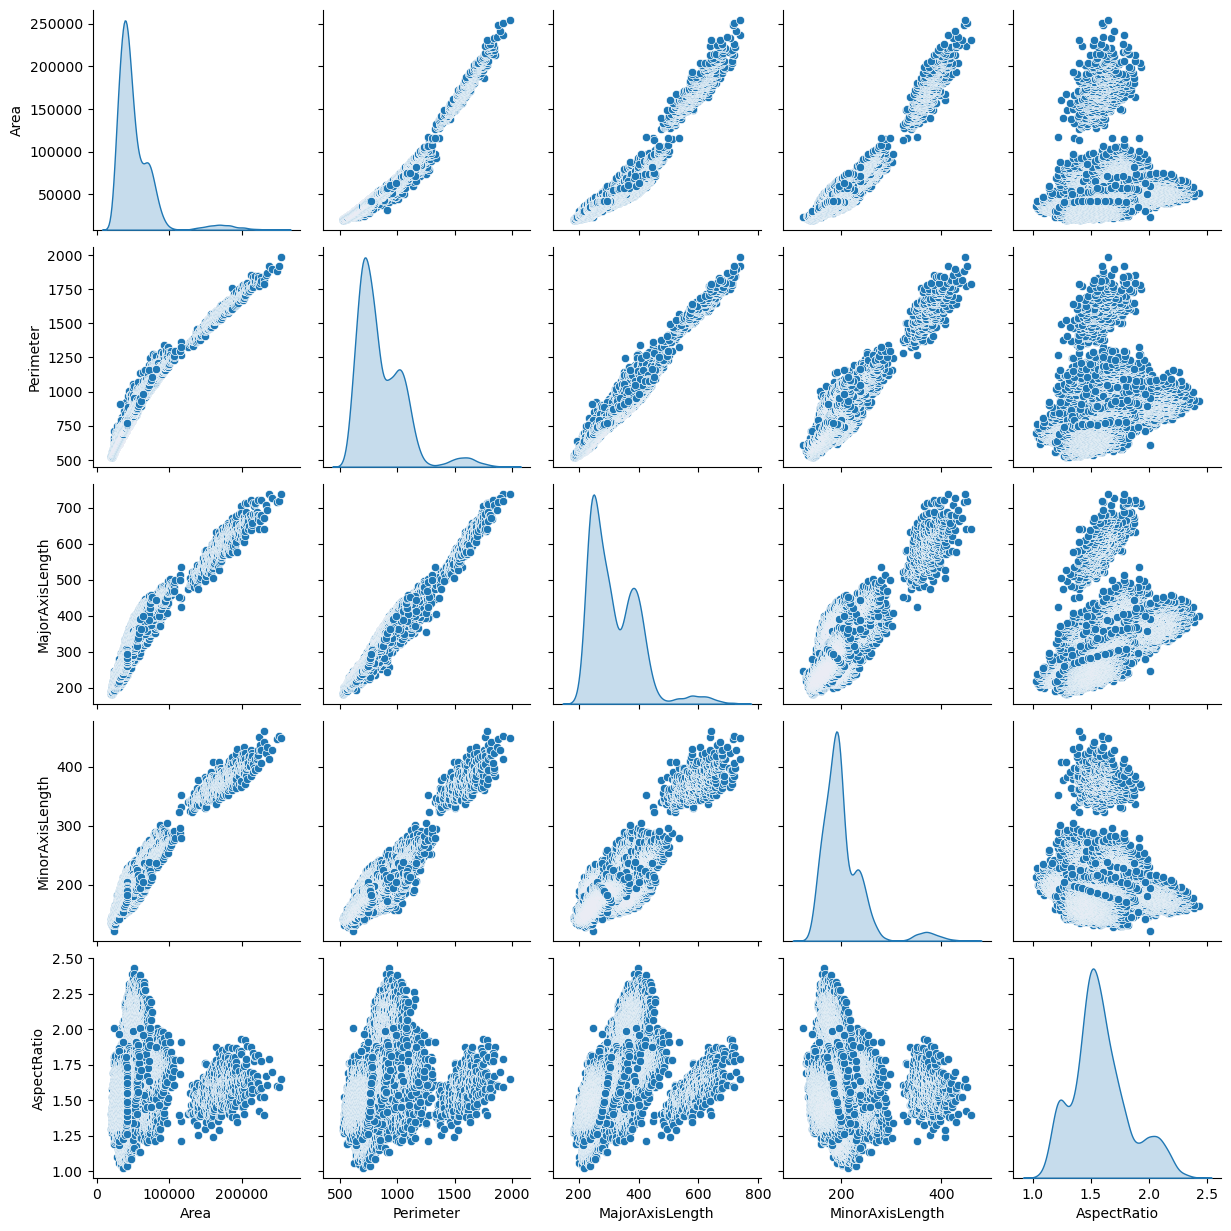

In [108]:
#Scatterplot (pairwise relationship)
sns.pairplot(df, diag_kind = "kde")
plt.show()

<h4><b>Scatterplot for data (NOT including outliers)</b></h4>

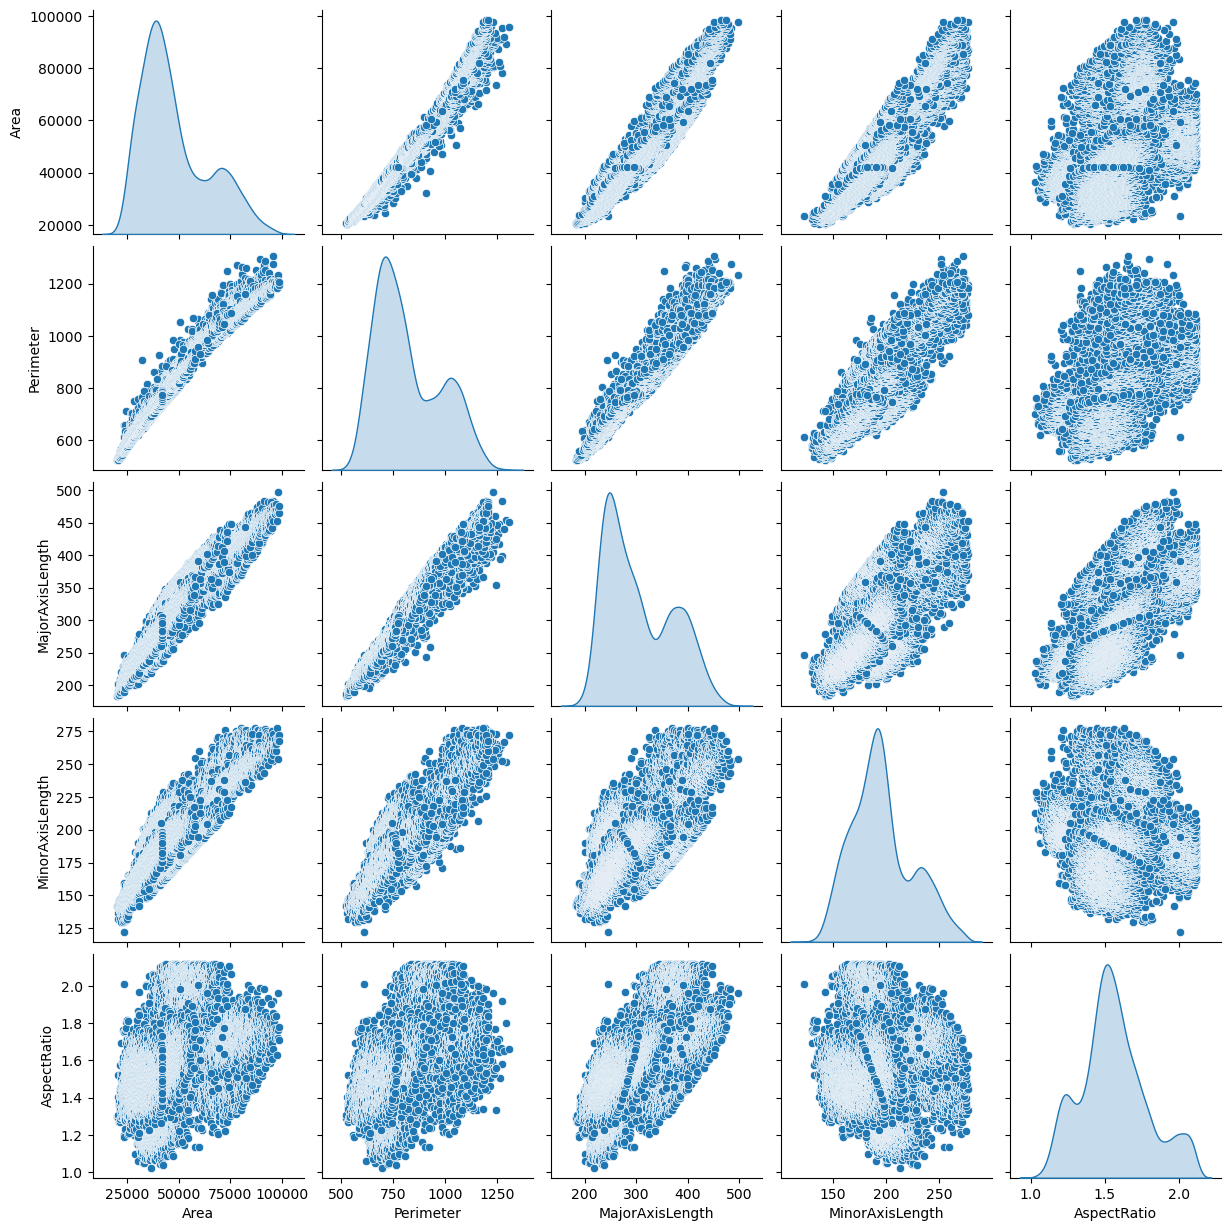

In [109]:
#Scatterplot (pairwise relationship) [NO OUTLIERS]
sns.pairplot(df_no_outliers, diag_kind = "kde")
plt.show()

<h4><b>Heatmap for data (including outliers)</b></h4>

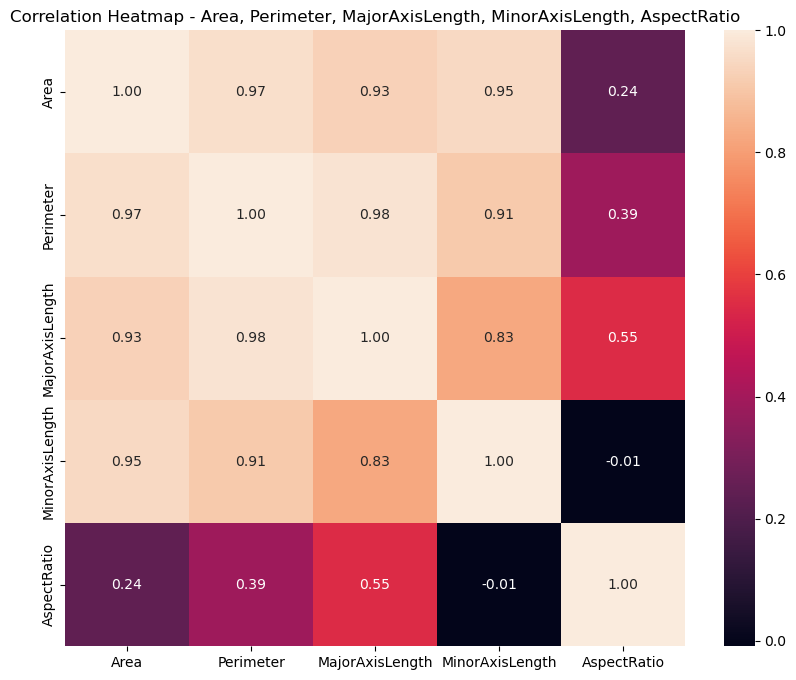

In [110]:
# Correlation Heatmap
plt.figure(figsize = (10, 8))
sns.heatmap(df.corr(), annot = True, fmt = ".2f")
plt.title("Correlation Heatmap - Area, Perimeter, MajorAxisLength, MinorAxisLength, AspectRatio")
plt.show()


<h4><b>Heatmap for data (NOT including outliers)</b></h4>

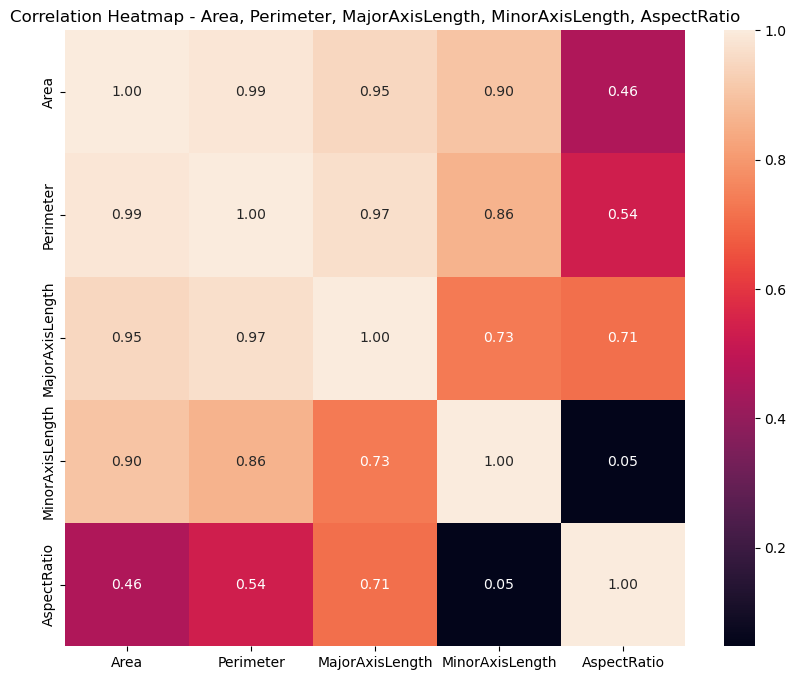

In [111]:
# Correlation Heatmap (NO OUTLIERS)
plt.figure(figsize = (10, 8))
sns.heatmap(df_no_outliers.corr(), annot = True, fmt = ".2f")
plt.title("Correlation Heatmap - Area, Perimeter, MajorAxisLength, MinorAxisLength, AspectRatio")
plt.show()

<h4><b>What Was Learned About the Dataset? (5-6 Sentences)</b></h4>

Examine a subset of features in the dataset both separately and in pairs. This may 
involve cleaning the dataset, for example removing missing values, applying 
transformations such as log scale and/or taking subsets. You have complete 
freedom in the selection of features to explore and any necessary filtering. Make 
sure to use suitable plots to examine variable distributions as well as pairwise 
relationships between variables. Consider how the presence of outliers acects the 
plots and consider removing them if they have a significant ecect. Explain what you 
learned about the dataset in 5-6 sentences.

-------

The exploratory analysis shows that the Dry Bean dataset holds many numeric features that vary in scale, such as Area, Perimeter, MajorAxisLength, MinorAxisLength, and Aspect Ratio. Most of the mentioned features have a roughly continous destribution along with potential outliers from extreimities. The pairwise relationships also show potential redundancy that could affect the models since there are features like Area and Perimeter that are highly correlated. Another issue is that the target classes are imbalanced and could negatively affect model performance, with classes like Bombay being underrepresented to the point that Bombay consists of less than half the rows of the next lowest class in terms of occurence count. Despite having some outliers removed through detection of extreme values, the dataset generally is very clean has clear seperation between classes based on the disteribution of features. This indicates that the dataset is well suited for a classification model and the selected features would perform well in predicting the class of dry bean.

<h3><b>Q2. Predictive Modeling</b></h3>

In [112]:
# Checking to see if there are any missing values in y
print(y.isna().sum())
# Since there are no missing values in any columns, no cleaning is needed

Class    0
dtype: int64


In [113]:
# Functions

# Print statistics
def printStats(predictionData, testingY):
    accuracy = accuracy_score(testingY, predictionData)
    print("Accuracy:", accuracy)
    # Precision
    precision = precision_score(testingY, predictionData, average = 'macro')
    print("Precision (macro):", precision)
    # Recall
    recall = recall_score(testingY, predictionData, average = 'macro')
    print("Recall (macro):", recall)
    # F1 Score
    f1 = f1_score(testingY, predictionData, average = 'macro')
    print("F1 Score (macro):", f1)
    # Confusion matrix
    cm = confusion_matrix(testingY, predictionData)
    print("Confusion Matrix:\n", cm)
    # Classification Report for all metrics
    cr = classification_report(testingY, predictionData)
    print("\nClassification Report:\n", cr)

    return accuracy, precision, recall, f1, cm, cr

# Prediction models (RF and KNN)
def predictiveModeling(features, target):
    common_index = features.index.intersection(target.index)
    modelX = features.loc[common_index]
    modelY = target.loc[common_index]
    trainingX, testingX, trainingY, testingY = train_test_split(
        modelX, modelY, test_size = 0.2, random_state = 42
    )
    # Standardize data
    scaler = StandardScaler()
    trainingXScaled = scaler.fit_transform(trainingX)
    testingXScaled = scaler.transform(testingX)
    # --- KNN Model
    knn = KNeighborsClassifier(n_neighbors = 5)
    knn.fit(trainingXScaled, trainingY.values.ravel())
    # Note: not using .values.ravel() presented a warning but the accuracy value
    # remained the same with or without it, so I chose to use .values.ravel()
    predictionDataKNN = knn.predict(testingXScaled)
    accuracy1, precision1, recall1, f11, cm1, cr1 = printStats(predictionDataKNN, testingY)
    # --- Random Forest Model
    rf = RandomForestClassifier(n_estimators = 200, random_state = 42)
    rf.fit(trainingX, trainingY.values.ravel())
    predictionDataRF = rf.predict(testingX)
    accuracy2, precision2, recall2, f12, cm2, cr2 = printStats(predictionDataRF, testingY)

    knnResults = [accuracy1, precision1, recall1, f11, cm1, cr1]
    rfResults = [accuracy2, precision2, recall2, f12, cm2, cr2]
    return knnResults, rfResults

In [114]:
# Results from the KNN and RF models (outliers not removed)
knnResults1, rfResults1 = predictiveModeling(df, y)

Accuracy: 0.9070877708409842
Precision (macro): 0.9186834588298229
Recall (macro): 0.9153138071447017
F1 Score (macro): 0.9167322009471306
Confusion Matrix:
 [[221   0  30   0   1   2   7]
 [  0 117   0   0   0   0   0]
 [ 18   0 292   0   5   0   2]
 [  0   0   0 614   2   9  46]
 [  2   0  11   4 382   0   9]
 [  4   0   0  13   0 384  12]
 [  0   0   2  53   6  15 460]]

Classification Report:
               precision    recall  f1-score   support

    BARBUNYA       0.90      0.85      0.87       261
      BOMBAY       1.00      1.00      1.00       117
        CALI       0.87      0.92      0.90       317
    DERMASON       0.90      0.92      0.91       671
       HOROZ       0.96      0.94      0.95       408
       SEKER       0.94      0.93      0.93       413
        SIRA       0.86      0.86      0.86       536

    accuracy                           0.91      2723
   macro avg       0.92      0.92      0.92      2723
weighted avg       0.91      0.91      0.91      2723

Ac

In [115]:
# Results from the KNN and RF models (outliers removed)
knnResults2, rfResults2 = predictiveModeling(df_no_outliers, y)

Accuracy: 0.8936678614097969
Precision (macro): 0.9043533114205218
Recall (macro): 0.8926864883614418
F1 Score (macro): 0.8979503834401403
Confusion Matrix:
 [[227  29   0   2   1   7]
 [ 13 310   0   4   0   5]
 [  0   0 628   1   9  48]
 [  1   7   2 255   0  18]
 [  5   0  23   0 373  12]
 [  1   1  62   5  11 451]]

Classification Report:
               precision    recall  f1-score   support

    BARBUNYA       0.92      0.85      0.88       266
        CALI       0.89      0.93      0.91       332
    DERMASON       0.88      0.92      0.90       686
       HOROZ       0.96      0.90      0.93       283
       SEKER       0.95      0.90      0.92       413
        SIRA       0.83      0.85      0.84       531

    accuracy                           0.89      2511
   macro avg       0.90      0.89      0.90      2511
weighted avg       0.90      0.89      0.89      2511

Accuracy: 0.8960573476702509
Precision (macro): 0.9046117519712809
Recall (macro): 0.8944218177306328
F1 Score 

In [116]:
# y (the original set of class labels for each of the 13611 rows)
# has 7 classes which can be seen below. The least commonly occuring
# class, Bombay, can be seen to NOT appear in y2, which is the set of
# class labels for each of the 12552 non outlier rows. This is because
# each instance of Bombay happened to be identified as an outlier
print("Original class counts:")
print(y.value_counts())
print(y.shape)

print("\nAfter outlier removal:")
common_index = df_no_outliers.index.intersection(y.index)
y2 = y.loc[common_index]
print(y2.value_counts())
print(y2.shape)

Original class counts:
Class   
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64
(13611, 1)

After outlier removal:
Class   
DERMASON    3546
SIRA        2636
SEKER       2027
CALI        1606
HOROZ       1455
BARBUNYA    1282
Name: count, dtype: int64
(12552, 1)


<h4><b>Noting Differences in Class Counts</b></h4>

Above we can see that in the first set of knn and rf results there are 7 classes. However, in the second set of knn and rf results there are only 6 classes. Originally, there were 13611 rows in the data, but after cleaning and removing outliers there are only 12552. The Bombay class initially had 522 instances in the data, which is smaller than the amount of rows removed from the original data, and now has none. This means that each instance of Bombay was removed likely because each instance was classified as an outlier. 

In [117]:
results = [knnResults1, rfResults1, knnResults2, rfResults2]
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
modelName = ["KNN with outliers", "Random Forest with Outliers", "KNN without outliers", "Random Forest without Outliers"]

# Iterate through each model and print metrics
for i, model_results in enumerate(results, start = 1):
    print("Model " + str(i) + ": " + modelName[i-1])
    for metric_name, value in zip(metrics, model_results[:4] + [model_results[4]]):  # exclude cm & cr
        print(f"  {metric_name}: {value:.4f}")
    print("\n")

Model 1: KNN with outliers
  Accuracy: 0.9071
  Precision: 0.9187
  Recall: 0.9153
  F1 Score: 0.9167


Model 2: Random Forest with Outliers
  Accuracy: 0.9100
  Precision: 0.9204
  Recall: 0.9179
  F1 Score: 0.9189


Model 3: KNN without outliers
  Accuracy: 0.8937
  Precision: 0.9044
  Recall: 0.8927
  F1 Score: 0.8980


Model 4: Random Forest without Outliers
  Accuracy: 0.8961
  Precision: 0.9046
  Recall: 0.8944
  F1 Score: 0.8991




<h4><b>Model Performance and Suitability of the Dataset (5-6 Sentences)</b></h4>

Decide on a problem to solve by developing predictive models using the data. This 
could be the same problem for which the dataset was intended or a dicerent 
problem that you believe can be addressed with this dataset. The solution could 
involve predicting a continuous variable (regression) or a categorical variable 
(classification). Consider what you learned about the variables during exploratory 
analysis to decide which features should be used as inputs to the models. The 
response variable (output of the model) is usually clear and is dictated by the 
problem being addressed. Train and evaluate two models and compare their 
results. The two models should utilize dicerent algorithms (e.g. kNN and Random 
Forest) but the same set of input variables. Classification models should be 
evaluated and compared using a confusion matrix and Precision/Recall 
measurements. Regression models should be evaluated using Mean Squared Error. 
Explain how models performed and comment on the suitability of the dataset to 
solve the problem you chose in 5-6 sentences.

-------

From the above results it is clear that both KNN and Random Forest models performed well on the dataset since they achieved high accuracy, precision, recall, and F1 scores. I decided to display the effectiveness of both models by using each one on the cleaned dataset and the cleaned dataset without outliers included. The Random Forest model outperformed the KNN model in its given dataset in all metrics, and the models which performed the best between both models were those which included outliers. This suggests that the data's natural variation included more useful information than noise. The high metrics of these models show that the features chosen (Area, Perimeter, MajorAxisLength, MinorAxisLength, AspectRatio) are highly predictive of the class labels, the models are not overly sensitive to outliers, and that the dataset is well suited for classification tasks since the classes are clearly seperable. Therefore it is safe to say that the KNN and Random Forest classification models are effective for this classification problem.

<h4><b>Meta-analysis </b></h4>

Discuss how the secondary aspects of the dataset helped or hindered the analysis. 
Consider the ecects of dataset structure, file format, metadata, contextual 
information, etc. on your analytics plan. These should roughly correspond to some 
of the areas of data management covered earlier in the course. If there are 
deficiencies in the dataset, provide recommendations to fix them. Three items 
should be sucicient.

-------

1. Creation of Logical Collections / Physical Data Handling:
    The dataset itself was clean and structured in a tabular format. This meant it was easily able to be loaded into pandas dataframes for efficient analysis. Little preprocessing was required since the data had no missing values. However, identification and removal of outliers resulted in an entire class being eliminated from the dataset due to its rarity compared to other classes. This means that there must be careful handling of the extreme values or creation of logical collections to ensure that all classes are preserved.


2. Metadata Collection, Management, and Access:
    The dataset included the names of different features along with descriptions. This made it signifagantly easier to deterimine what the meaning of each column was and helped inform my feature selection in the exploratory analysis. The data was also separated into different dataframes which were fairly intuitive if someone needed to figure out from scratch (dry_bean.data.features,
    dry_bean.data.targets, dry_bean.metadata, dry_bean.variables). Unfortunately, the data types provided for each column were not particularly helpful, since only 2 of them were identified as integers. Everything else was either "continuous" or "classification". The presentation of the metadata was also concrete, including basically everything anyone would ever need to know about the dataset, suchb as an abstract, author, creation data, url, etc.

3. Knowledge and Information Discovery:
    The dataset was simple to use in exploratory analysis since it included numeric features and a categorical target. This meant that visualization was also incredibly straightforward and was able to be used to illustrate the usefulness and distribution of different features. Additionally, contextual information like feature descriptions were useful in determining which features would be related to each other and determine correlations, such as the correlation between Area and Perimeter. However, the dataset should also include guidance on how to handle outliers due to the potential of eliminating such as small class. Whether this is a statement saying that outliers do not need to be removed or instructions on how to perform such a task, it is important to preserve all classes in the dataset for the best classification, as was seen with the models.